In [2]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [3]:
data=load_iris()
X=data.data
y=data.target

In [13]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=1)


In [14]:
model=DecisionTreeClassifier(random_state=1)
model.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,1
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [15]:
y_pred=model.predict(X_test)

acc=accuracy_score(y_test,y_pred)
print(f"Accuracy Score:{acc:.2f}")

Accuracy Score:0.97


In [20]:
#Hyperparameter tuning with decision tree classifier using grid search
from sklearn.model_selection import GridSearchCV
param_grid={
    'max_depth':range(1,10,1),
    'min_samples_leaf':range(1,20,2),
    'min_samples_split':range(2,20,2),
    'criterion':["entropy","gini"]
}
tree=DecisionTreeClassifier(random_state=1)
grid_search=GridSearchCV(estimator=tree,param_grid=param_grid,cv=5,verbose=True)
grid_search.fit(X_train,y_train)

print("Best Accuracy;",grid_search.best_score_)
print(grid_search.best_estimator_)

Fitting 5 folds for each of 1620 candidates, totalling 8100 fits
Best Accuracy; 0.9666666666666668
DecisionTreeClassifier(max_depth=4, random_state=1)


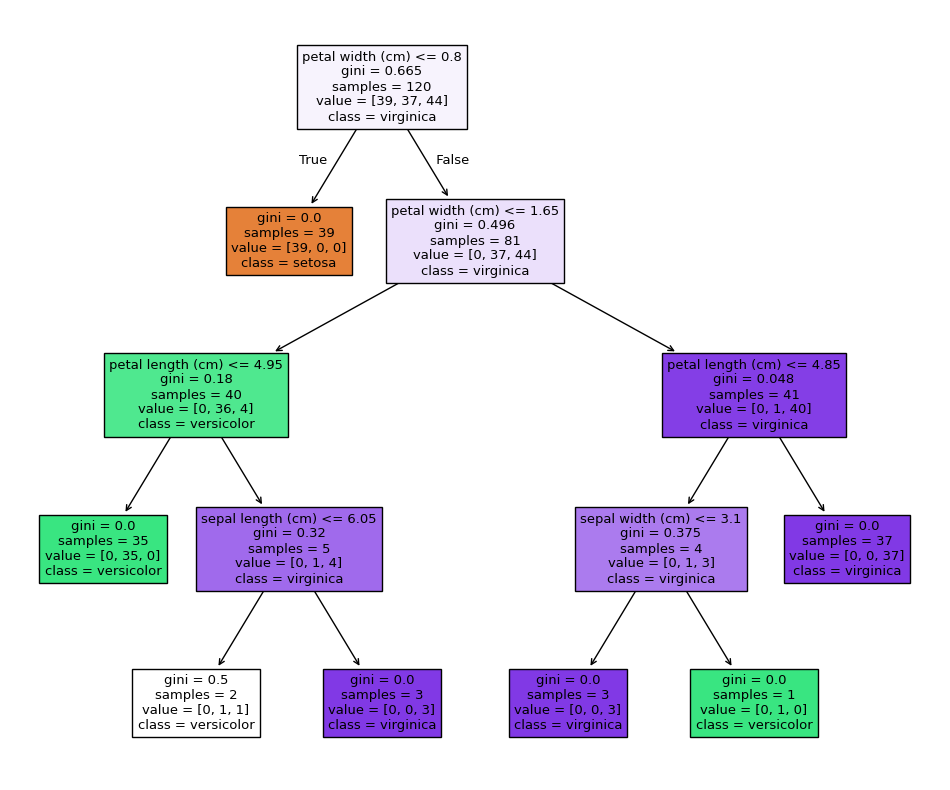

In [24]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

best=grid_search.best_estimator_

plt.figure(figsize=(12,10))
plot_tree(best,filled=True,feature_names=data.feature_names,class_names=data.target_names)
plt.show()